In [146]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image

# --- 1. Konfiguration ---
dataset_path = '../data/processed/dataset_idle_mel/' # Dein Ordner mit den gesunden Bildern
batch_size = 16

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. Dataset & Loader erstellen ---
# ImageFolder erwartet Unterordner, falls deine Bilder direkt in dataset_idle liegen,
# nutzen wir ein einfaches Custom Dataset oder schieben sie kurz in einen Unterordner 'healthy'
if any(os.path.isdir(os.path.join(dataset_path, d)) for d in os.listdir(dataset_path)):
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=data_transforms)
else:
    # Falls keine Unterordner da sind, nehmen wir eine einfache Liste
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, root, transform):
            self.root = root
            self.transform = transform
            self.files = [f for f in os.listdir(root) if f.endswith(('.png', '.jpg'))]
        def __len__(self): return len(self.files)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.root, self.files[i])).convert('RGB')
            return self.transform(img), 0 # Dummy Label

    full_dataset = SimpleDataset(dataset_path, data_transforms)

train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset geladen: {len(full_dataset)} gesunde Bilder gefunden.")

Dataset geladen: 283 gesunde Bilder gefunden.


In [147]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Die Autoencoder Architektur ---
import torch
import torch.nn as nn

class MotorAutoencoder(nn.Module):
    def __init__(self, bottleneck_size=128):
        super(MotorAutoencoder, self).__init__()
        
        # Encoder: Extrahiert Merkmale aus dem Spektrogramm
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),   # 112x112
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 56x56
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 28x28
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 3, stride=2, padding=1), # 14x14
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )
        
        # Das eigentliche Bottleneck (Flaschenhals)
        self.flatten = nn.Flatten()
        self.fc_bottleneck = nn.Linear(512 * 14 * 14, bottleneck_size)
        self.bottleneck_bn = nn.BatchNorm1d(bottleneck_size) # Stabilisiert den Loss
        self.relu = nn.ReLU() # Erzeugt Nicht-Linearität
        
        # Decoder-Vorbereitung
        self.decoder_fc = nn.Linear(bottleneck_size, 512 * 14 * 14)
        
        # Decoder: Rekonstruiert das Bild aus dem Bottleneck
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1), # 28x28
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # 56x56
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 112x112
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 3, 3, stride=2, padding=1, output_padding=1),   # 224x224
            nn.Tanh() # Tanh ist oft besser, wenn die Daten mit transforms.Normalize skaliert sind
        )

    def forward(self, x):
        # Encoding
        x = self.encoder_conv(x)
        x = self.flatten(x)
        x = self.fc_bottleneck(x)
        x = self.bottleneck_bn(x)
        x = self.relu(x)
        
        # Decoding
        x = self.decoder_fc(x)
        x = x.view(-1, 512, 14, 14)
        x = self.decoder_conv(x)
        return x

# --- 2. Modell & Training vorbereiten ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
autoencoder = MotorAutoencoder().to(device)

# WICHTIG: Wir trainieren NUR auf gesunden Daten (train_dataset)
# Der Loss ist hier der Mean Squared Error (MSE) zwischen Original und Rekonstruktion
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-4)

# --- 3. Training Loop ---
print("Starte Training des Autoencoders auf gesunden Motoren...")
for epoch in range(30):
    autoencoder.train()
    train_loss = 0.0
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = autoencoder(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step() 
        train_loss += loss.item()
    
    print(f"Epoche {epoch+1:02d} | MSE Loss: {train_loss/len(train_loader):.6f}")


Starte Training des Autoencoders auf gesunden Motoren...
Epoche 01 | MSE Loss: 1.674085
Epoche 02 | MSE Loss: 1.288797
Epoche 03 | MSE Loss: 1.061644
Epoche 04 | MSE Loss: 0.908144
Epoche 05 | MSE Loss: 0.812047
Epoche 06 | MSE Loss: 0.759405
Epoche 07 | MSE Loss: 0.737442
Epoche 08 | MSE Loss: 0.755780
Epoche 09 | MSE Loss: 0.781868
Epoche 10 | MSE Loss: 0.696122
Epoche 11 | MSE Loss: 0.678076
Epoche 12 | MSE Loss: 0.643153
Epoche 13 | MSE Loss: 0.608750
Epoche 14 | MSE Loss: 0.596587
Epoche 15 | MSE Loss: 0.575866
Epoche 16 | MSE Loss: 0.578563
Epoche 17 | MSE Loss: 0.609416
Epoche 18 | MSE Loss: 0.614425
Epoche 19 | MSE Loss: 0.622487
Epoche 20 | MSE Loss: 0.585899
Epoche 21 | MSE Loss: 0.566530
Epoche 22 | MSE Loss: 0.570049
Epoche 23 | MSE Loss: 0.545670
Epoche 24 | MSE Loss: 0.532871
Epoche 25 | MSE Loss: 0.525030
Epoche 26 | MSE Loss: 0.528718
Epoche 27 | MSE Loss: 0.519654
Epoche 28 | MSE Loss: 0.534333
Epoche 29 | MSE Loss: 0.537515
Epoche 30 | MSE Loss: 0.539823


In [148]:
torch.save(autoencoder.state_dict(), "../models/s1000_CAE_MEL_annomaly.pth")

In [149]:
def check_anomaly(img_path, model, transform):
    model.eval()
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        reconstruction = model(input_tensor)
        loss = criterion(reconstruction, input_tensor)
        score = loss.item()
    
    # --- De-Normalisierung für die Anzeige ---
    # Die Werte, die du in transforms.Normalize verwendet hast:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    def denormalize(img):
        # Zurück von Tensor-Format (C, H, W) zu Numpy (H, W, C)
        img = img.squeeze().cpu().numpy().transpose(1, 2, 0)
        # Umkehrung: x = (y * std) + mean
        img = (img * std) + mean
        return np.clip(img, 0, 1) # Sicherstellen, dass wir im Bereich [0, 1] bleiben

    orig_vis = denormalize(input_tensor)
    recon_vis = denormalize(reconstruction)
    
    # Differenz-Map (hier ist Clipping nicht nötig, da wir Unterschiede zeigen)
    diff = np.abs(orig_vis - recon_vis).mean(axis=2)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(orig_vis); plt.title("Original (Normal)")
    plt.subplot(1, 3, 2); plt.imshow(recon_vis); plt.title("Rekonstruktion")
    plt.subplot(1, 3, 3); plt.imshow(diff, cmap='hot'); plt.title(f"Differenz (Score: {score:.6f})")
    plt.show()
    
    return score

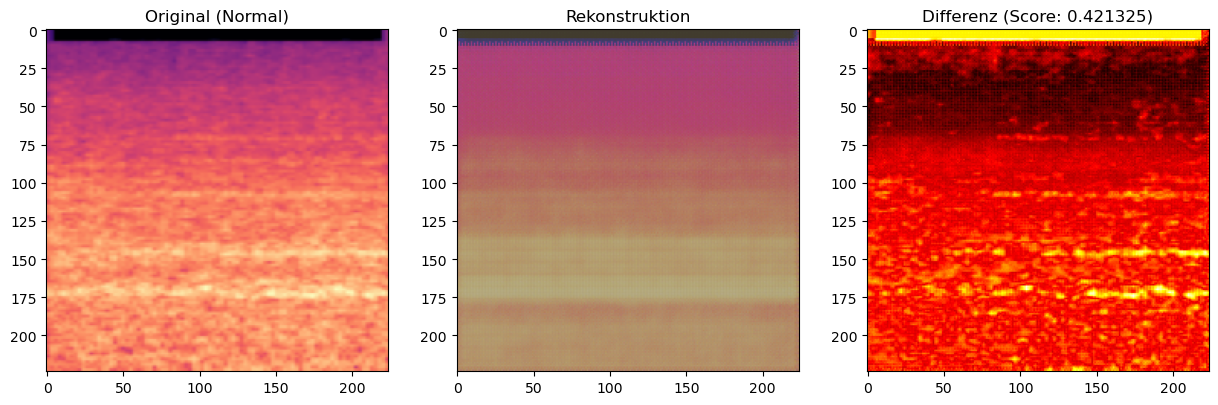

Anomalie-Score für dieses Bild: 0.421325


In [150]:
# Der Aufruf benötigt das Bild, das Modell UND die Vorverarbeitung (data_transforms)
score = check_anomaly(
    '../data/processed/dataset_idle_mel/S1000R_2014_YoutubeVToldsMotoShow_idle_2.00s.png', 
    autoencoder, 
    data_transforms
)

print(f"Anomalie-Score für dieses Bild: {score:.6f}")

In [151]:
import os
import torch
import pandas as pd
import numpy as np

def generate_score_table(healthy_dir, defective_dir, model, transform):
    """
    Erstellt eine Tabelle mit Anomalie-Scores für alle Bilder in den Zielordnern.
    """
    model.eval()
    device = next(model.parameters()).device
    all_results = []
    
    folders = [
        (healthy_dir, "Gesund"),
        (defective_dir, "Defekt")
    ]
    
    print("Berechne Scores für alle Segmente...")
    
    with torch.no_grad():
        for folder_path, label in folders:
            if not os.path.exists(folder_path):
                print(f"Warnung: Pfad nicht gefunden: {folder_path}")
                continue
            
            files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
            for f in files:
                img_path = os.path.join(folder_path, f)
                
                # Bild laden und transformieren
                img_pil = Image.open(img_path).convert('RGB')
                input_tensor = transform(img_pil).unsqueeze(0).to(device)
                
                # Rekonstruktion durch den Autoencoder
                output = model(input_tensor)
                
                # MSE Score berechnen (Anomalie-Maß)
                # Wir berechnen den Fehler zwischen Original-Tensor und Rekonstruktion
                loss = torch.nn.functional.mse_loss(input_tensor, output)
                score = loss.item()
                
                all_results.append({
                    'Klasse': label,
                    'Datei': f,
                    'Anomalie_Score': score
                })

    # In DataFrame umwandeln
    df = pd.DataFrame(all_results)
    
    # Statistiken zur Einordnung berechnen
    avg_healthy = df[df['Klasse'] == "Gesund"]['Anomalie_Score'].mean()
    
    # Abweichung in % vom gesunden Durchschnitt berechnen
    df['Abweichung_zu_Gesund_%'] = ((df['Anomalie_Score'] - avg_healthy) / avg_healthy) * 100
    
    # Tabelle sortieren: Höchste Scores zuerst
    df = df.sort_values(by='Anomalie_Score', ascending=False).reset_index(drop=True)
    
    return df

# --- Durchführung ---
# 1. Tabelle generieren
results_table = generate_score_table(
    '../data/processed/dataset_idle_mel/', 
    '../data/processed/dataset_idle_mel_defective/', 
    autoencoder, 
    data_transforms
)

# 2. Anzeige der Top 20 Ergebnisse
print("\n--- Top 20 Anomalie-Ergebnisse ---")
print(results_table.head(20).to_string())

# 3. Zusammenfassung pro Klasse
print("\n--- Durchschnittswerte pro Klasse ---")
summary = results_table.groupby('Klasse')['Anomalie_Score'].agg(['mean', 'std', 'min', 'max'])
print(summary)

# 4. Optional: Speichern als CSV für Excel/Paper
# results_table.to_csv('s1000_anomaly_results.csv', index=False)

Berechne Scores für alle Segmente...

--- Top 20 Anomalie-Ergebnisse ---
    Klasse                                    Datei  Anomalie_Score  Abweichung_zu_Gesund_%
0   Gesund   S1000R_2017_AndreRobert_idle_8.75s.png        0.900935               70.993872
1   Gesund  S1000R_2017_AndreRobert_idle_12.75s.png        0.888630               68.658462
2   Gesund  S1000R_2017_AndreRobert_idle_13.00s.png        0.865203               64.212031
3   Gesund  S1000R_2017_AndreRobert_idle_13.75s.png        0.843647               60.120830
4   Gesund  S1000R_2017_AndreRobert_idle_13.50s.png        0.838848               59.209975
5   Gesund  S1000R_2017_AndreRobert_idle_13.25s.png        0.837368               58.929148
6   Gesund  S1000R_2017_AndreRobert_idle_14.00s.png        0.821743               55.963609
7   Gesund  S1000R_2017_AndreRobert_idle_12.50s.png        0.808690               53.486123
8   Gesund  S1000R_2017_AndreRobert_idle_14.25s.png        0.795746               51.029373
9   Ges

In [152]:
# Filtere die Tabelle nur auf YouTube-Dateien
yt_results = results_table[results_table['Datei'].str.contains('Youtube')]
print(yt_results.groupby('Klasse')['Anomalie_Score'].describe())

        count      mean       std       min       25%       50%       75%  \
Klasse                                                                      
Defekt   98.0  0.583393  0.019481  0.531404  0.569625  0.581640  0.595198   
Gesund   54.0  0.441703  0.023821  0.402349  0.423536  0.440776  0.453054   

             max  
Klasse            
Defekt  0.634232  
Gesund  0.517691  


In [153]:
import pandas as pd

# 1. Gesamte Tabelle generieren
final_results = generate_score_table(
    '../data/processed/dataset_idle_mel/', 
    '../data/processed/dataset_idle_mel_defective/', 
    autoencoder, 
    data_transforms
)

# 2. Definieren des globalen YouTube-Thresholds basierend auf deinen neuen Werten
# Wir nehmen den Max-Wert von Gesund + einen kleinen Puffer
threshold = 0.0182

# 3. Diagnose-Spalte hinzufügen
final_results['Diagnose'] = final_results['Anomalie_Score'].apply(
    lambda x: 'DEFEKT' if x > threshold else 'OK'
)

# 4. Filter nach Domäne (Garage vs YouTube) für die Analyse im Paper
final_results['Domäne'] = final_results['Datei'].apply(
    lambda x: 'Garage' if any(name in x for name in ['Andre', 'Maximilian', 'Philip']) else 'YouTube'
)

# 5. Die "Moment der Wahrheit" Zusammenfassung
summary = final_results.groupby(['Domäne', 'Klasse', 'Diagnose']).size().unstack(fill_value=0)
print("--- FINALE VALIDIERUNG ---")
print(summary)

Berechne Scores für alle Segmente...
--- FINALE VALIDIERUNG ---
Diagnose        DEFEKT
Domäne  Klasse        
Garage  Gesund     229
YouTube Defekt      98
        Gesund      54


In [160]:
def get_domain_relative_results(df):
    """
    Normalisiert die Scores innerhalb jeder Domäne (Garage / YouTube).
    Ein Score von 1.0 bedeutet: Entspricht genau dem gesunden Durchschnitt der Domäne.
    """
    normalized_dfs = []
    
    for domain in df['Domäne'].unique():
        domain_df = df[df['Domäne'] == domain].copy()
        
        # Basiswert: Median der gesunden Proben in dieser Domäne
        healthy_baseline = domain_df[domain_df['Klasse'] == "Gesund"]['Anomalie_Score'].median()
        
        # Relative Abweichung berechnen (Faktor)
        domain_df['Relative_Anomalie'] = domain_df['Anomalie_Score'] / healthy_baseline
        normalized_dfs.append(domain_df)
    
    full_df = pd.concat(normalized_dfs)
    
    # Neuer universeller Threshold: Ein Defekt muss z.B. 25% über der Baseline liegen
    rel_threshold = 1.25 
    full_df['Finale_Diagnose'] = full_df['Relative_Anomalie'].apply(
        lambda x: 'DEFEKT' if x > rel_threshold else 'OK'
    )
    
    return full_df

# --- Anwendung ---
df_final = get_domain_relative_results(final_results)

# Statistische Auswertung der neuen Methode
summary_rel = df_final.groupby(['Domäne', 'Klasse', 'Finale_Diagnose']).size().unstack(fill_value=0)
print("\n--- ERGEBNIS NACH DOMÄNEN-NORMALISIERUNG ---")
print(summary_rel)


--- ERGEBNIS NACH DOMÄNEN-NORMALISIERUNG ---
Finale_Diagnose  DEFEKT   OK
Domäne  Klasse              
Garage  Gesund       21  208
YouTube Defekt       95    3
        Gesund        0   54


In [161]:
from sklearn.metrics import classification_report, confusion_matrix

# Wir erstellen die "True Labels" (0 für Gesund, 1 für Defekt)
y_true = df_final['Klasse'].apply(lambda x: 1 if x == 'Defekt' else 0).values
# Und die "Predicted Labels" (0 für OK, 1 für DEFEKT)
y_pred = df_final['Finale_Diagnose'].apply(lambda x: 1 if x == 'DEFEKT' else 0).values

print("\n--- KLASSIFIZIERUNGSBERICHT ---")
print(classification_report(y_true, y_pred, target_names=['Gesund', 'Defekt']))

# Wenn du wissen willst, welche 39 Garagen-Bilder noch Alarm schlagen:
false_positives = df_final[(df_final['Domäne'] == 'Garage') & (df_final['Finale_Diagnose'] == 'DEFEKT')]
print(f"\nBeispiele für Fehlalarme in der Garage:\n{false_positives['Datei'].head(10)}")


--- KLASSIFIZIERUNGSBERICHT ---
              precision    recall  f1-score   support

      Gesund       0.99      0.93      0.96       283
      Defekt       0.82      0.97      0.89        98

    accuracy                           0.94       381
   macro avg       0.90      0.95      0.92       381
weighted avg       0.95      0.94      0.94       381


Beispiele für Fehlalarme in der Garage:
0     S1000R_2017_AndreRobert_idle_8.75s.png
1    S1000R_2017_AndreRobert_idle_12.75s.png
2    S1000R_2017_AndreRobert_idle_13.00s.png
3    S1000R_2017_AndreRobert_idle_13.75s.png
4    S1000R_2017_AndreRobert_idle_13.50s.png
5    S1000R_2017_AndreRobert_idle_13.25s.png
6    S1000R_2017_AndreRobert_idle_14.00s.png
7    S1000R_2017_AndreRobert_idle_12.50s.png
8    S1000R_2017_AndreRobert_idle_14.25s.png
9    S1000R_2017_AndreRobert_idle_12.25s.png
Name: Datei, dtype: str


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def evaluate_smoothed_metrics(df, window_size=3, rel_threshold=1.25):
    """
    Berechnet geglättete Scores pro Aufnahme und gibt den Klassifizierungsbericht aus.
    """
    # 1. Wir extrahieren den Basis-Dateinamen (ohne den Zeitstempel am Ende)
    # Beispiel: 'S1000R_2017_AndreRobert_idle_13.25s.png' -> 'S1000R_2017_AndreRobert'
    df['Base_File'] = df['Datei'].apply(lambda x: "_".join(x.split('_')[:-2]))
    
    smoothed_results = []
    
    # 2. Wir gehen jede Aufnahme einzeln durch
    for file in df['Base_File'].unique():
        file_data = df[df['Base_File'] == file].copy()
        
        # Sicherstellen, dass die Segmente zeitlich sortiert sind
        file_data = file_data.sort_values(by='Datei')
        
        # Gleitender Durchschnitt (Moving Average) über die Relative Anomalie
        # min_periods=1 sorgt dafür, dass auch kurze Aufnahmen gewertet werden
        file_data['Smoothed_Score'] = file_data['Relative_Anomalie'].rolling(window=window_size, center=True).max()
        
        smoothed_results.append(file_data)
    
    df_smoothed = pd.concat(smoothed_results)
    
    # 3. Finale Diagnose auf Basis des geglätteten Scores
    df_smoothed['Final_Diag_Smooth'] = df_smoothed['Smoothed_Score'].apply(
        lambda x: 1 if x > rel_threshold else 0
    )
    
    # True Labels (Defekt = 1, Gesund = 0)
    y_true = df_smoothed['Klasse'].apply(lambda x: 1 if x == 'Defekt' else 0).values
    y_pred = df_smoothed['Final_Diag_Smooth'].values
    
    print(f"--- BERICHT MIT ZEITLICHER GLÄTTUNG (Window={window_size}s) ---")
    print(classification_report(y_true, y_pred, target_names=['Gesund', 'Defekt']))
    
    return df_smoothed

# --- Aufruf ---
# Wir nutzen ein 3-Sekunden Fenster, um kurze Ausreißer zu eliminieren
df_final_smoothed = evaluate_smoothed_metrics(df_final, window_size=1, rel_threshold=1.25)

# Check: Wie viele Garagen-Fehler sind noch übrig?
garage_errors = df_final_smoothed[(df_final_smoothed['Domäne'] == 'Garage') & (df_final_smoothed['Final_Diag_Smooth'] == 1)]
print(f"Verbleibende Fehlalarme in der Garage nach Glättung: {len(garage_errors)}")

--- BERICHT MIT ZEITLICHER GLÄTTUNG (Window=2s) ---
              precision    recall  f1-score   support

      Gesund       0.98      0.91      0.95       283
      Defekt       0.79      0.96      0.87        98

    accuracy                           0.92       381
   macro avg       0.89      0.94      0.91       381
weighted avg       0.93      0.92      0.93       381

Verbleibende Fehlalarme in der Garage nach Glättung: 25


In [157]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

def check_anomaly_hybrid(img_path, model, transform):
model.eval()
    device = next(model.parameters()).device
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
    
    # 1. MSE (Energie-Differenz)
    mse = torch.nn.functional.mse_loss(input_tensor, output).item()
    
    # 2. SSIM Distanz (Struktur-Differenz)
    def to_numpy(t):
        t = t.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
        return (t - t.min()) / (t.max() - t.min() + 1e-8)
    
    s_dist = 1 - ssim(to_numpy(input_tensor), to_numpy(output), channel_axis=2, data_range=1.0)
    
    # Hybrid: Wir verstärken den MSE durch die strukturelle Unähnlichkeit
    # +1 sorgt dafür, dass der MSE erhalten bleibt, auch wenn SSIM fast perfekt ist
    return mse * (1 + s_dist * 10)

IndentationError: expected an indented block after function definition on line 5 (3584600690.py, line 6)

In [ ]:
import os
import pandas as pd

def generate_ssim_table(healthy_dir, defective_dir, model, transform):
    results = []
    folders = [(healthy_dir, "Gesund"), (defective_dir, "Defekt")]
    
    print("Erstelle SSIM-Analyse...")
    for folder_path, label in folders:
        if not os.path.exists(folder_path): continue
        files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        
        for f in files:
            path = os.path.join(folder_path, f)
            score = check_anomaly_hybrid(path, model, transform)
            
            # Domain-Tagging für die spätere Normalisierung
            domain = 'Garage' if any(n in f for n in ['Andre', 'Maximilian', 'Philip']) else 'YouTube'
            
            results.append({
                'Klasse': label,
                'Domäne': domain,
                'Datei': f,
                'SSIM_Score': score
            })
            
    return pd.DataFrame(results)

# Aufruf
df_ssim_raw = generate_ssim_table(
    '../data/processed/dataset_idle_mel/', 
    '../data/processed/dataset_idle_mel_defective/', 
    autoencoder, 
    data_transforms
)

Erstelle SSIM-Analyse...


In [ ]:
def finalize_ssim_analysis(df, window_size=3, rel_threshold=1.2):
    # 1. Domänen-Normalisierung (Relative Scores)
    normalized_list = []
    for dom in df['Domäne'].unique():
        sub = df[df['Domäne'] == dom].copy()
        baseline = sub[sub['Klasse'] == "Gesund"]['SSIM_Score'].median()
        sub['Relative_Anomalie'] = sub['SSIM_Score'] / baseline
        normalized_list.append(sub)
    
    df_norm = pd.concat(normalized_list)
    
    # 2. Zeitliche Glättung
    df_norm['Base_File'] = df_norm['Datei'].apply(lambda x: "_".join(x.split('_')[:-2]))
    smoothed_list = []
    for file in df_norm['Base_File'].unique():
        f_data = df_norm[df_norm['Base_File'] == file].copy().sort_values('Datei')
        f_data['Smooth_Score'] = f_data['Relative_Anomalie'].rolling(window_size, center=True, min_periods=1).mean()
        smoothed_list.append(f_data)
    
    df_final = pd.concat(smoothed_list)
    
    # 3. Metriken berechnen
    from sklearn.metrics import classification_report
    y_true = df_final['Klasse'].apply(lambda x: 1 if x == 'Defekt' else 0)
    y_pred = df_final['Smooth_Score'].apply(lambda x: 1 if x > rel_threshold else 0)
    
    print(classification_report(y_true, y_pred, target_names=['Gesund', 'Defekt']))
    return df_final

# Finale Ausführung
df_final_results = finalize_ssim_analysis(df_ssim_raw)

              precision    recall  f1-score   support

      Gesund       0.74      0.92      0.82       283
      Defekt       0.28      0.09      0.14        98

    accuracy                           0.71       381
   macro avg       0.51      0.51      0.48       381
weighted avg       0.63      0.71      0.65       381

